# Territorial Digital Divide: Geospatial Raster Analysis — Cusco Region

**Course:** Python Programming — Applied Data Science  
**Dataset 1:** NASA Black Marble VNL 2025 (nighttime lights, EPSG:4326)  
**Dataset 2:** OSIPTEL Mobile Coverage Kernel Density 2019 (EPSG:32719)  
**Region:** Cusco, Peru

## Step 0 — Environment Setup

In [1]:
!pip install rasterio numpy matplotlib scipy seaborn pandas -q

import rasterio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import scipy
from scipy import ndimage, stats
import seaborn as sns
import pandas as pd
import os
import math
import warnings
warnings.filterwarnings('ignore')

print(f"rasterio:    {rasterio.__version__}")
print(f"numpy:       {np.__version__}")
print(f"matplotlib:  {matplotlib.__version__}")
print(f"scipy:       {scipy.__version__}")
print(f"seaborn:     {sns.__version__}")
print(f"pandas:      {pd.__version__}")

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


rasterio:    1.5.0
numpy:       2.3.5
matplotlib:  3.10.6
scipy:       1.16.3
seaborn:     0.13.2
pandas:      2.3.3


## Step 1 — Raster Loading and Inspection

In [2]:
import rasterio
import numpy as np

def inspect_raster(path, name):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
        print(f"\n{'='*58}")
        print(f"Raster: {name}")
        print(f"  CRS:             {src.crs}")
        print(f"  Shape (H x W):   {src.height} x {src.width}")
        print(f"  Band count:      {src.count}")
        print(f"  NoData value:    {nodata}")
        print(f"  Data type:       {src.dtypes[0]}")
        print(f"  Bounding box:    {src.bounds}")
        res_x = src.transform.a
        res_y = abs(src.transform.e)
        print(f"  Resolution:      {res_x:.6f}deg x {res_y:.6f}deg  (~{res_x*111.32:.4f} km x {res_y*111.32:.4f} km)")
        if nodata is not None:
            valid_mask = (data != nodata) & (~np.isnan(data))
        else:
            valid_mask = ~np.isnan(data)
        valid_px = int(np.sum(valid_mask))
        total_px = data.size
        print(f"  Valid pixels:    {valid_px:,} / {total_px:,} ({100*valid_px/total_px:.1f}%)")
        valid_data = data[valid_mask]
        if len(valid_data) > 0:
            print(f"  Value range:     [{valid_data.min():.4f}, {valid_data.max():.4f}]")
        return data, src.profile, src.bounds, src.transform

vnl_path  = "../data/VNL_cusco_2025.tif"
conn_path = "../data/kernel_cobmovil2019_50m.tif"

vnl_arr,  vnl_profile,  vnl_bounds,  vnl_transform  = inspect_raster(vnl_path,  "VNL Nighttime Lights (NASA)")
conn_arr, conn_profile, conn_bounds, conn_transform = inspect_raster(conn_path, "Mobile Connectivity (OSIPTEL)")


Raster: VNL Nighttime Lights (NASA)
  CRS:             EPSG:4326
  Shape (H x W):   1081 x 961
  Band count:      1
  NoData value:    None
  Data type:       float32
  Bounding box:    BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  Resolution:      0.004167deg x 0.004167deg  (~0.4638 km x 0.4638 km)
  Valid pixels:    1,038,841 / 1,038,841 (100.0%)


  Value range:     [-1.5000, 1254.6145]



Raster: Mobile Connectivity (OSIPTEL)
  CRS:             EPSG:32719
  Shape (H x W):   6116 x 7754
  Band count:      1
  NoData value:    -3.4028234663852886e+38
  Data type:       float32
  Bounding box:    BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  Resolution:      50.000000deg x 50.000000deg  (~5566.0000 km x 5566.0000 km)
  Valid pixels:    47,423,464 / 47,423,464 (100.0%)


  Value range:     [0.0000, 0.0000]


## Step 2 — Reprojection and Grid Alignment

In [3]:
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import rasterio
import os

os.makedirs("../data",   exist_ok=True)
os.makedirs("../output", exist_ok=True)

conn_reproj_path  = "../data/conn_reprojected.tif"
conn_aligned_path = "../data/conn_aligned.tif"

# --- Step 2a: Reproject connectivity EPSG:32719 -> EPSG:4326 ---
with rasterio.open(conn_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, "EPSG:4326", src.width, src.height, *src.bounds
    )
    profile = src.profile.copy()
    profile.update({"crs": "EPSG:4326", "transform": transform,
                    "width": width, "height": height})
    with rasterio.open(conn_reproj_path, "w", **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs="EPSG:4326",
            resampling=Resampling.bilinear
        )
print(f"Reprojected -> {conn_reproj_path}")

# --- Step 2b: Resample to exact VNL grid ---
with rasterio.open(vnl_path) as ref:
    ref_transform = ref.transform
    ref_crs       = ref.crs
    ref_profile   = ref.profile.copy()

with rasterio.open(conn_reproj_path) as src:
    profile2 = ref_profile.copy()
    profile2.update({"dtype": "float32"})
    with rasterio.open(conn_aligned_path, "w", **profile2) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=ref_crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )
print(f"Aligned to VNL grid -> {conn_aligned_path}")

# --- Reload arrays ---
with rasterio.open(vnl_path) as src:
    vnl_arr    = src.read(1).astype(np.float32)
    vnl_nodata = src.nodata

with rasterio.open(conn_aligned_path) as src:
    conn_arr    = src.read(1).astype(np.float32)
    conn_nodata = src.nodata

print(f"\nVNL shape:          {vnl_arr.shape}")
print(f"Connectivity shape: {conn_arr.shape}")
assert vnl_arr.shape == conn_arr.shape, "ERROR: Shapes do not match!"
print("Verification: Both arrays share identical dimensions.")

Reprojected -> ../data/conn_reprojected.tif


Aligned to VNL grid -> ../data/conn_aligned.tif

VNL shape:          (1081, 961)
Connectivity shape: (1081, 961)
Verification: Both arrays share identical dimensions.


## Step 3 — Robust Normalization [2nd–98th Percentile]

In [4]:
import numpy as np

def robust_normalize(arr, nodata=None, p_low=2, p_high=98):
    """Percentile-based normalization to [0,1]. Negatives and NoData -> 0 first."""
    data = arr.copy().astype(np.float32)
    data[data < 0] = 0
    if nodata is not None:
        data[data == nodata] = 0
    data[np.isnan(data)] = 0
    data[np.isinf(data)] = 0
    valid = data[data > 0]
    if len(valid) == 0:
        return data
    p_lo = np.percentile(valid, p_low)
    p_hi = np.percentile(valid, p_high)
    data = np.clip(data, p_lo, p_hi)
    if p_hi > p_lo:
        data = (data - p_lo) / (p_hi - p_lo)
    return np.clip(data, 0, 1)

vnl_norm  = robust_normalize(vnl_arr,  nodata=vnl_nodata)
conn_norm = robust_normalize(conn_arr, nodata=conn_nodata)

print("VNL Normalized:")
print(f"  min={vnl_norm.min():.4f}  max={vnl_norm.max():.4f}  "
      f"mean={vnl_norm.mean():.4f}  std={vnl_norm.std():.4f}")
print("\nConnectivity Normalized:")
print(f"  min={conn_norm.min():.4f}  max={conn_norm.max():.4f}  "
      f"mean={conn_norm.mean():.4f}  std={conn_norm.std():.4f}")

# Shared extent for all maps
extent = [vnl_bounds.left, vnl_bounds.right, vnl_bounds.bottom, vnl_bounds.top]

VNL Normalized:
  min=0.0000  max=1.0000  mean=0.0035  std=0.0414

Connectivity Normalized:
  min=0.0000  max=1.0000  mean=0.0142  std=0.0807


## Step 4 — Map 1: VNL Nighttime Lights (Raw and Normalized)

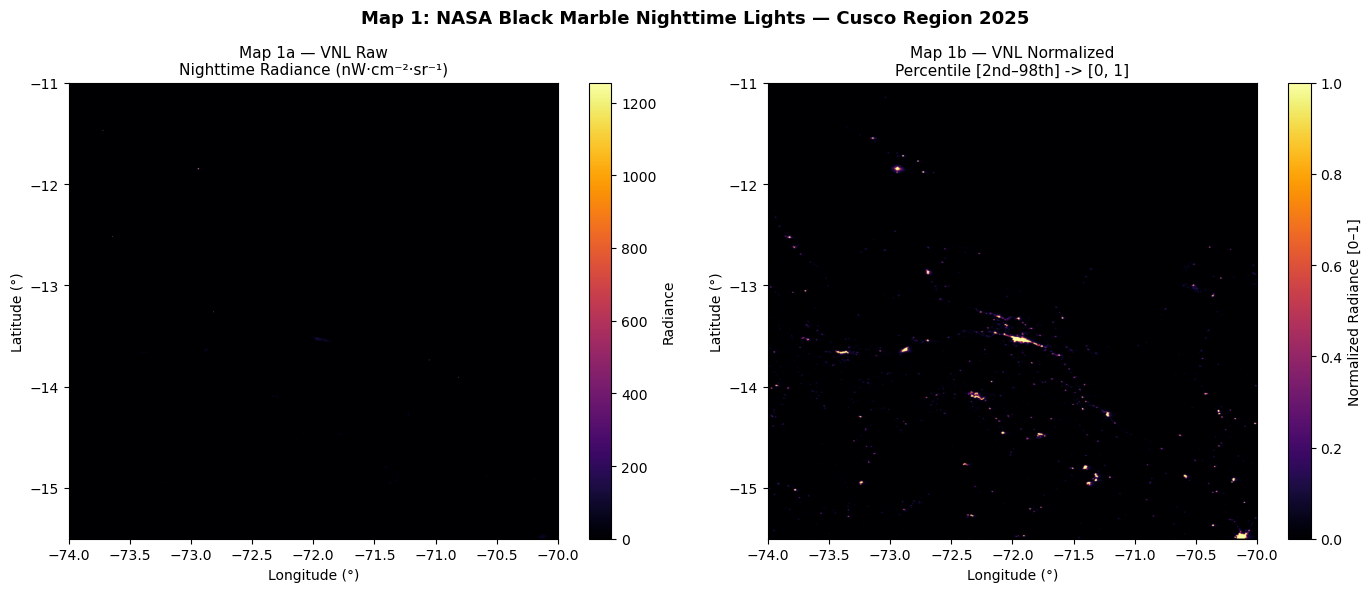

Observation: Bright zones indicate areas with significant artificial lighting at night,
serving as a proxy for urbanization and population concentration. The brightest cluster
corresponds to the city of Cusco and nearby towns, while the predominantly dark areas
reveal the vast rural Andean highlands with minimal electricity and human activity.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

vnl_display = vnl_arr.copy().astype(float)
if vnl_nodata is not None:
    vnl_display[vnl_arr == vnl_nodata] = np.nan
vnl_display[vnl_display < 0] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(vnl_display, cmap="inferno", extent=extent, aspect="auto")
axes[0].set_title("Map 1a — VNL Raw\nNighttime Radiance (nW·cm⁻²·sr⁻¹)", fontsize=11)
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
plt.colorbar(im0, ax=axes[0], label="Radiance")

im1 = axes[1].imshow(vnl_norm, cmap="inferno", extent=extent, aspect="auto", vmin=0, vmax=1)
axes[1].set_title("Map 1b — VNL Normalized\nPercentile [2nd–98th] -> [0, 1]", fontsize=11)
axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")
plt.colorbar(im1, ax=axes[1], label="Normalized Radiance [0–1]")

plt.suptitle("Map 1: NASA Black Marble Nighttime Lights — Cusco Region 2025",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/map1_vnl_nighttime.png", dpi=150, bbox_inches="tight")
plt.show()

print("Observation: Bright zones indicate areas with significant artificial lighting at night,")
print("serving as a proxy for urbanization and population concentration. The brightest cluster")
print("corresponds to the city of Cusco and nearby towns, while the predominantly dark areas")
print("reveal the vast rural Andean highlands with minimal electricity and human activity.")

## Step 5 — Map 2: Digital Divide Index (IBD) and Exclusion Index (EDT)

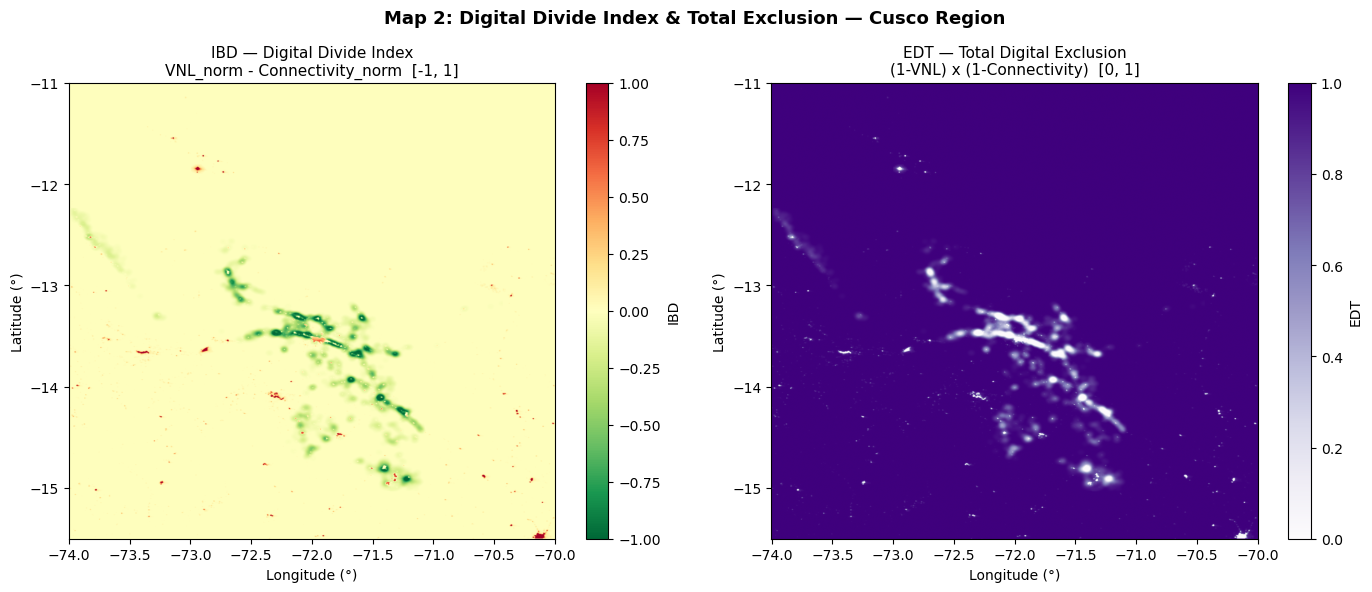

IBD Interpretation:
  Red zones (IBD > 0): High nighttime light but low connectivity -> active digital divide.
  Urbanized areas that have not yet received adequate internet infrastructure.
  Green zones (IBD < 0): Relatively well-connected compared to their lighting level.

EDT Interpretation:
  High purple values: Areas with neither light nor connectivity -> maximum double exclusion.
  Zones representing the most critically marginalized rural communities: both economically
  isolated AND digitally disconnected, typically in remote high-altitude Andean areas.


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Compute indices
IBD = vnl_norm - conn_norm                    # range [-1, 1]
EDT = (1 - vnl_norm) * (1 - conn_norm)        # range [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(IBD, cmap="RdYlGn_r", extent=extent, aspect="auto", vmin=-1, vmax=1)
axes[0].set_title("IBD — Digital Divide Index\nVNL_norm - Connectivity_norm  [-1, 1]", fontsize=11)
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
plt.colorbar(im0, ax=axes[0], label="IBD")

im1 = axes[1].imshow(EDT, cmap="Purples", extent=extent, aspect="auto", vmin=0, vmax=1)
axes[1].set_title("EDT — Total Digital Exclusion\n(1-VNL) x (1-Connectivity)  [0, 1]", fontsize=11)
axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")
plt.colorbar(im1, ax=axes[1], label="EDT")

plt.suptitle("Map 2: Digital Divide Index & Total Exclusion — Cusco Region",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/map2_ibd_edt.png", dpi=150, bbox_inches="tight")
plt.show()

print("IBD Interpretation:")
print("  Red zones (IBD > 0): High nighttime light but low connectivity -> active digital divide.")
print("  Urbanized areas that have not yet received adequate internet infrastructure.")
print("  Green zones (IBD < 0): Relatively well-connected compared to their lighting level.")
print("")
print("EDT Interpretation:")
print("  High purple values: Areas with neither light nor connectivity -> maximum double exclusion.")
print("  Zones representing the most critically marginalized rural communities: both economically")
print("  isolated AND digitally disconnected, typically in remote high-altitude Andean areas.")

## Step 6 — Map 3: Intervention Priority (3 Levels)

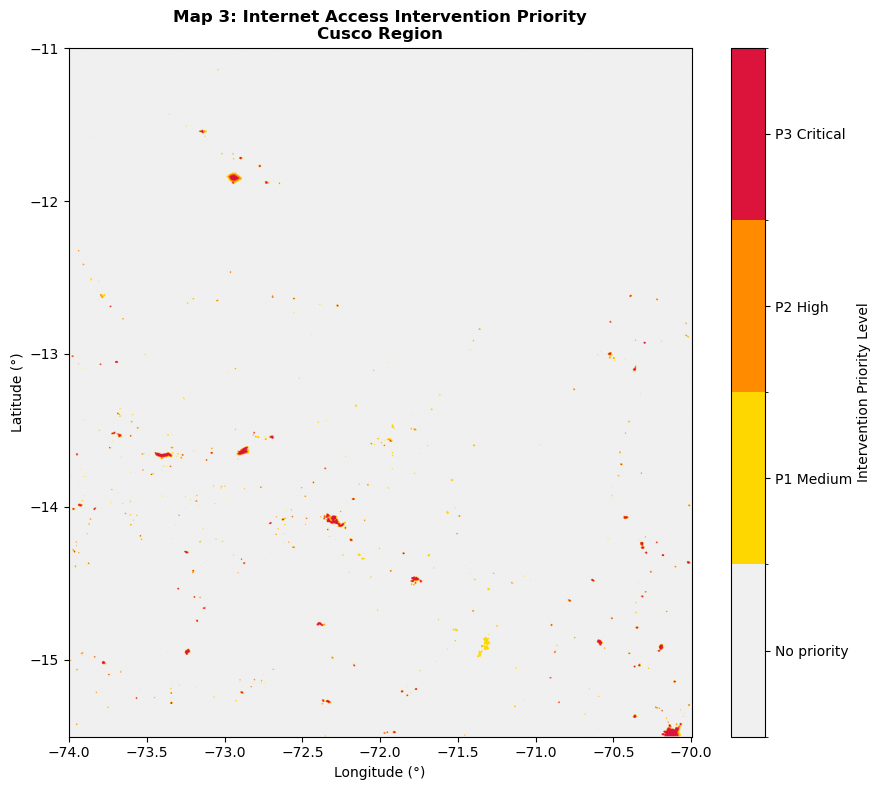

  Medium (P1) (VNL>=0.10, Conn<0.25): 1,570 pixels (0.15%)
  High (P2) (VNL>=0.15, Conn<0.15): 1,267 pixels (0.12%)
  Critical (P3) (VNL>=0.30, Conn<0.10): 1,589 pixels (0.15%)
  No priority: 1,034,415 pixels (99.57%)


In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

priority = np.zeros(vnl_norm.shape, dtype=np.uint8)
priority[(vnl_norm >= 0.10) & (conn_norm < 0.25)] = 1   # P1 Medium
priority[(vnl_norm >= 0.15) & (conn_norm < 0.15)] = 2   # P2 High
priority[(vnl_norm >= 0.30) & (conn_norm < 0.10)] = 3   # P3 Critical

cmap_priority = mcolors.ListedColormap(["#f0f0f0", "#FFD700", "#FF8C00", "#DC143C"])
bounds_p      = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_p        = mcolors.BoundaryNorm(bounds_p, cmap_priority.N)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(priority, cmap=cmap_priority, norm=norm_p, extent=extent, aspect="auto")
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(["No priority", "P1 Medium", "P2 High", "P3 Critical"])
cbar.set_label("Intervention Priority Level")
ax.set_title("Map 3: Internet Access Intervention Priority\nCusco Region",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
plt.tight_layout()
plt.savefig("../output/map3_priority.png", dpi=150, bbox_inches="tight")
plt.show()

total = priority.size
levels = [(1, "Medium (P1)", "VNL>=0.10, Conn<0.25"),
          (2, "High (P2)",   "VNL>=0.15, Conn<0.15"),
          (3, "Critical (P3)","VNL>=0.30, Conn<0.10")]
for level, name, cond in levels:
    count = int(np.sum(priority == level))
    pct   = 100 * count / total
    print(f"  {name} ({cond}): {count:,} pixels ({pct:.2f}%)")
no_prio = int(np.sum(priority == 0))
print(f"  No priority: {no_prio:,} pixels ({100*no_prio/total:.2f}%)")

## Step 7 — Map 4: Social Exclusion Risk

75th percentile risk threshold: 1.0000
90th percentile risk threshold: 1.0000


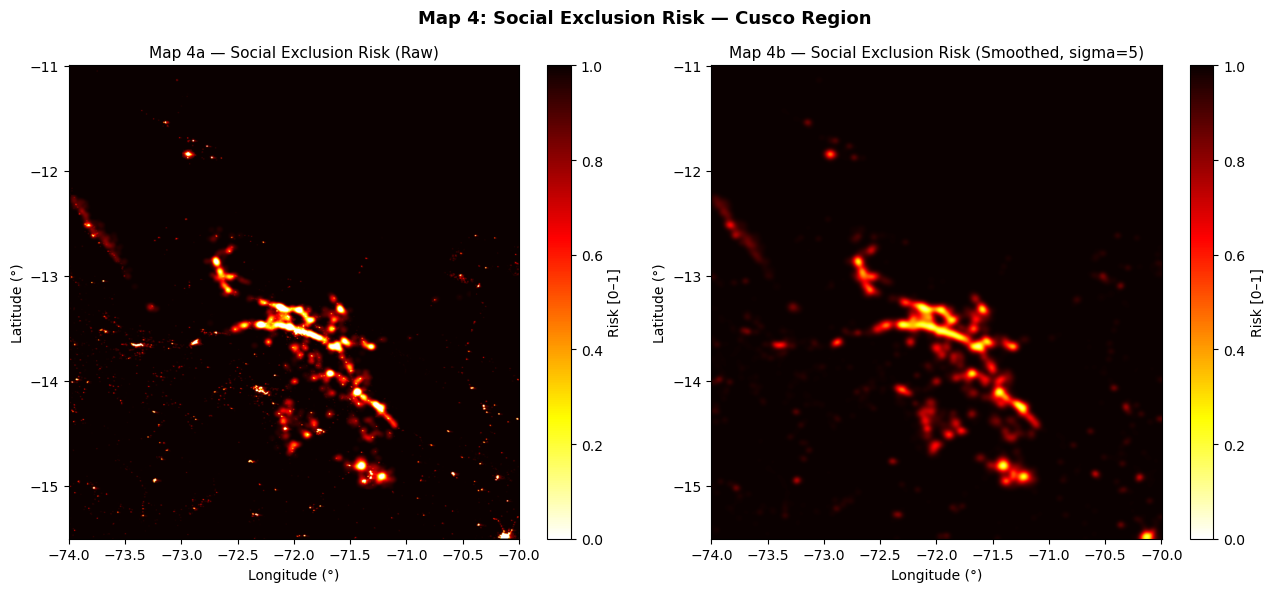

In [8]:
from scipy import ndimage
import matplotlib.pyplot as plt
import numpy as np

# Risk = EDT * (1 - VNL_norm), then normalize to [0,1]
risk_raw = EDT * (1 - vnl_norm)
r_min, r_max = risk_raw.min(), risk_raw.max()
risk_norm_r  = (risk_raw - r_min) / (r_max - r_min + 1e-10)

# Gaussian spatial filter sigma=5
risk_smooth = ndimage.gaussian_filter(risk_norm_r, sigma=5)
risk_smooth = np.clip(risk_smooth, 0, 1)

p75 = np.percentile(risk_norm_r, 75)
p90 = np.percentile(risk_norm_r, 90)
print(f"75th percentile risk threshold: {p75:.4f}")
print(f"90th percentile risk threshold: {p90:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

im0 = axes[0].imshow(risk_norm_r, cmap="hot_r", extent=extent, aspect="auto", vmin=0, vmax=1)
axes[0].set_title("Map 4a — Social Exclusion Risk (Raw)", fontsize=11)
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
plt.colorbar(im0, ax=axes[0], label="Risk [0–1]")

im1 = axes[1].imshow(risk_smooth, cmap="hot_r", extent=extent, aspect="auto", vmin=0, vmax=1)
axes[1].set_title("Map 4b — Social Exclusion Risk (Smoothed, sigma=5)", fontsize=11)
axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")
plt.colorbar(im1, ax=axes[1], label="Risk [0–1]")

plt.suptitle("Map 4: Social Exclusion Risk — Cusco Region", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/map4_social_risk.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Territorial Classification (2x2 Grid)

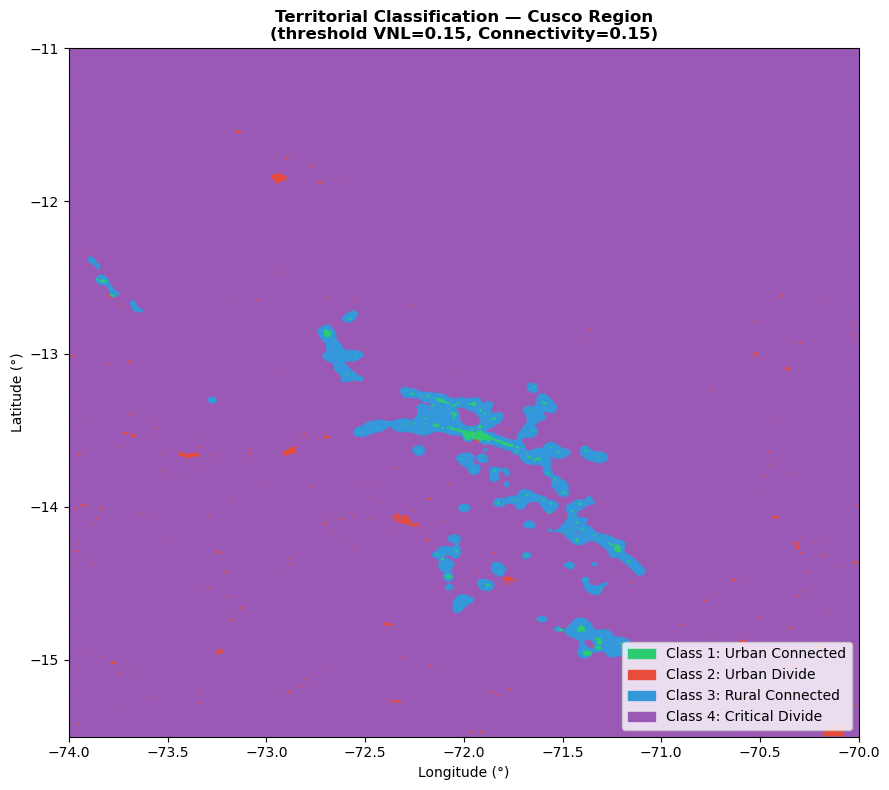

 Class            Name  Pixel Count  Percentage (%)  Area (km2)
     1 Urban Connected         2098            0.20      436.38
     2    Urban Divide         2856            0.27      594.04
     3 Rural Connected        26551            2.56     5522.50
     4 Critical Divide      1007336           96.97   209521.87

Saved: output/clasificacion_brecha.tif


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import rasterio
import math

thr_vnl  = 0.15
thr_conn = 0.15

classification = np.zeros(vnl_norm.shape, dtype=np.uint8)
classification[(vnl_norm >= thr_vnl) & (conn_norm >= thr_conn)] = 1  # Urban Connected
classification[(vnl_norm >= thr_vnl) & (conn_norm <  thr_conn)] = 2  # Urban Divide
classification[(vnl_norm <  thr_vnl) & (conn_norm >= thr_conn)] = 3  # Rural Connected
classification[(vnl_norm <  thr_vnl) & (conn_norm <  thr_conn)] = 4  # Critical Divide

class_names  = {1: "Urban Connected", 2: "Urban Divide",
                3: "Rural Connected", 4: "Critical Divide"}
class_colors = {1: "#2ECC71", 2: "#E74C3C", 3: "#3498DB", 4: "#9B59B6"}

cmap_class = mcolors.ListedColormap(["#CCCCCC", "#2ECC71", "#E74C3C", "#3498DB", "#9B59B6"])
bounds_c   = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm_c     = mcolors.BoundaryNorm(bounds_c, cmap_class.N)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(classification, cmap=cmap_class, norm=norm_c, extent=extent, aspect="auto")
patches = [mpatches.Patch(color=class_colors[k], label=f"Class {k}: {class_names[k]}")
           for k in [1, 2, 3, 4]]
ax.legend(handles=patches, loc="lower right", fontsize=10)
ax.set_title("Territorial Classification — Cusco Region\n(threshold VNL=0.15, Connectivity=0.15)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
plt.tight_layout()
plt.savefig("../output/map5_classification.png", dpi=150, bbox_inches="tight")
plt.show()

# Approximate pixel area at Cusco latitude (~-13.5deg)
res_lat_deg = abs(vnl_transform.e)
res_lon_deg = vnl_transform.a
area_px_km2 = (res_lat_deg * 111.0) * (res_lon_deg * 111.0 * abs(math.cos(math.radians(-13.5))))

rows = []
total_px = classification.size
for cls_id in [1, 2, 3, 4]:
    count = int(np.sum(classification == cls_id))
    rows.append({
        "Class": cls_id,
        "Name": class_names[cls_id],
        "Pixel Count": count,
        "Percentage (%)": round(100 * count / total_px, 2),
        "Area (km2)": round(count * area_px_km2, 2),
    })
df_class = pd.DataFrame(rows)
print(df_class.to_string(index=False))

# Save classification raster
class_profile = vnl_profile.copy()
class_profile.update({"dtype": "uint8", "nodata": 0})
with rasterio.open("../output/clasificacion_brecha.tif", "w", **class_profile) as dst:
    dst.write(classification.astype(np.uint8), 1)
print("\nSaved: output/clasificacion_brecha.tif")

## Step 9 — Statistical Summary

=== Descriptive Statistics by Class ===


                    VNL                         Connectivity                  \
                   mean     std     min     max         mean     std     min   
Class Name                                                                     
Critical Divide  0.0008  0.0066  0.0000  0.1499       0.0029  0.0152  0.0000   
Rural Connected  0.0146  0.0268  0.0000  0.1499       0.3940  0.2393  0.1500   
Urban Connected  0.5179  0.3257  0.1500  1.0000       0.6554  0.3066  0.1504   
Urban Divide     0.4807  0.3129  0.1502  1.0000       0.0059  0.0228  0.0000   

                            IBD                          
                    max    mean     std     min     max  
Class Name                                               
Critical Divide  0.1500 -0.0021  0.0162 -0.1500  0.1499  
Rural Connected  1.0000 -0.3795  0.2318 -1.0000 -0.0108  
Urban Connected  1.0000 -0.1375  0.4284 -0.8498  0.8434  
Urban Divide     0.1486  0.4748  0.3152  0.0074  1.0000  

Pearson Correlation (VNL vs Conn

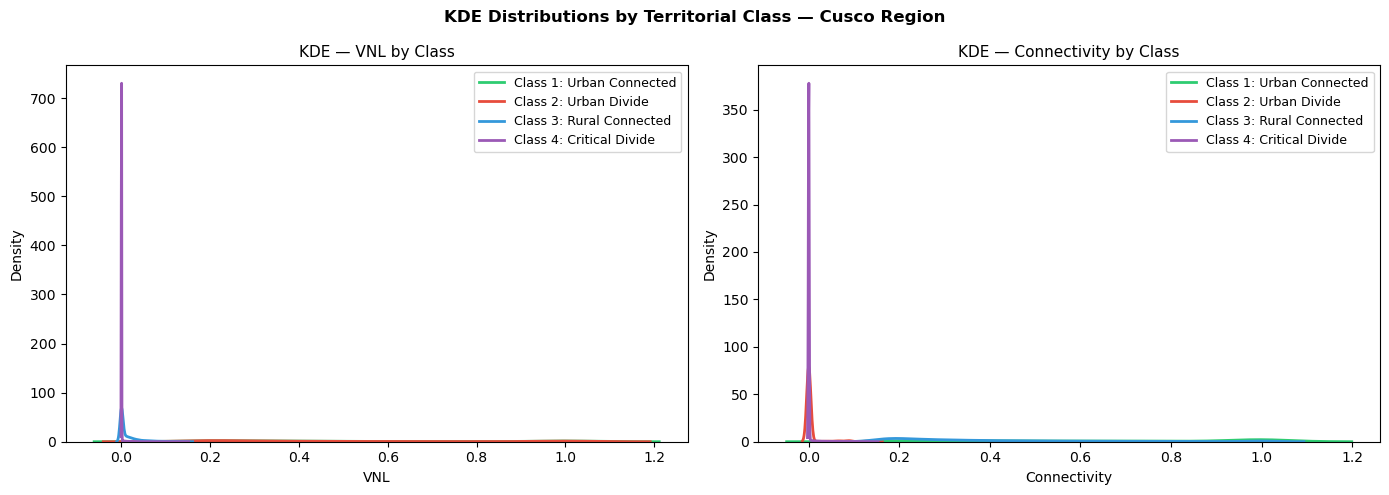


Welch's t-test — VNL: Class 1 (Urban Connected) vs Class 4 (Critical Divide)
  t-statistic = 72.7309
  p-value     = 0.00e+00
  Cohen's d   = 31.8627
  Result: Statistically significant (p < 0.05)


In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

class_flat = classification.ravel()
vnl_flat   = vnl_norm.ravel()
conn_flat  = conn_norm.ravel()
ibd_flat   = IBD.ravel()
valid_mask = class_flat > 0

df_full = pd.DataFrame({
    "Class":       class_flat[valid_mask],
    "Class Name":  [class_names[c] for c in class_flat[valid_mask]],
    "VNL":         vnl_flat[valid_mask],
    "Connectivity": conn_flat[valid_mask],
    "IBD":         ibd_flat[valid_mask],
})

print("=== Descriptive Statistics by Class ===")
stats_df = df_full.groupby("Class Name")[["VNL", "Connectivity", "IBD"]].agg(
    ["mean", "std", "min", "max"]
)
print(stats_df.round(4))

# Pearson correlation (every 40th pixel)
vnl_sub  = vnl_norm[::40, ::40].ravel()
conn_sub = conn_norm[::40, ::40].ravel()
cls_sub  = classification[::40, ::40].ravel()
mask_sub = cls_sub > 0
r, p_val_r = stats.pearsonr(vnl_sub[mask_sub], conn_sub[mask_sub])
print(f"\nPearson Correlation (VNL vs Connectivity, every 40th pixel):")
print(f"  r = {r:.4f},  p-value = {p_val_r:.2e}")

# KDE plots
palette = {1: "#2ECC71", 2: "#E74C3C", 3: "#3498DB", 4: "#9B59B6"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["VNL", "Connectivity"]):
    for cls_id in [1, 2, 3, 4]:
        subset = df_full[df_full["Class"] == cls_id][col]
        sns.kdeplot(data=subset, ax=ax, color=palette[cls_id],
                    label=f"Class {cls_id}: {class_names[cls_id]}", linewidth=2)
    ax.set_title(f"KDE — {col} by Class", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
plt.suptitle("KDE Distributions by Territorial Class — Cusco Region",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/kde_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Welch t-test: Class 1 vs Class 4
c1 = df_full[df_full["Class"] == 1]["VNL"].values
c4 = df_full[df_full["Class"] == 4]["VNL"].values
t_stat, p_val_t = stats.ttest_ind(c1, c4, equal_var=False)
n1, n4 = len(c1), len(c4)
pooled_std = np.sqrt(((n1-1)*c1.std()**2 + (n4-1)*c4.std()**2) / (n1+n4-2))
cohens_d   = (c1.mean() - c4.mean()) / (pooled_std + 1e-10)

print(f"\nWelch's t-test — VNL: Class 1 (Urban Connected) vs Class 4 (Critical Divide)")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value     = {p_val_t:.2e}")
print(f"  Cohen's d   = {cohens_d:.4f}")
print(f"  Result: {'Statistically significant (p < 0.05)' if p_val_t < 0.05 else 'Not significant'}")

## Step 10 — Export Deliverables

Saved: ../output/vnl_norm.tif
Saved: ../output/conn_norm.tif
Saved: ../output/ibd_brecha_digital.tif
(clasificacion_brecha.tif already saved in Step 8)


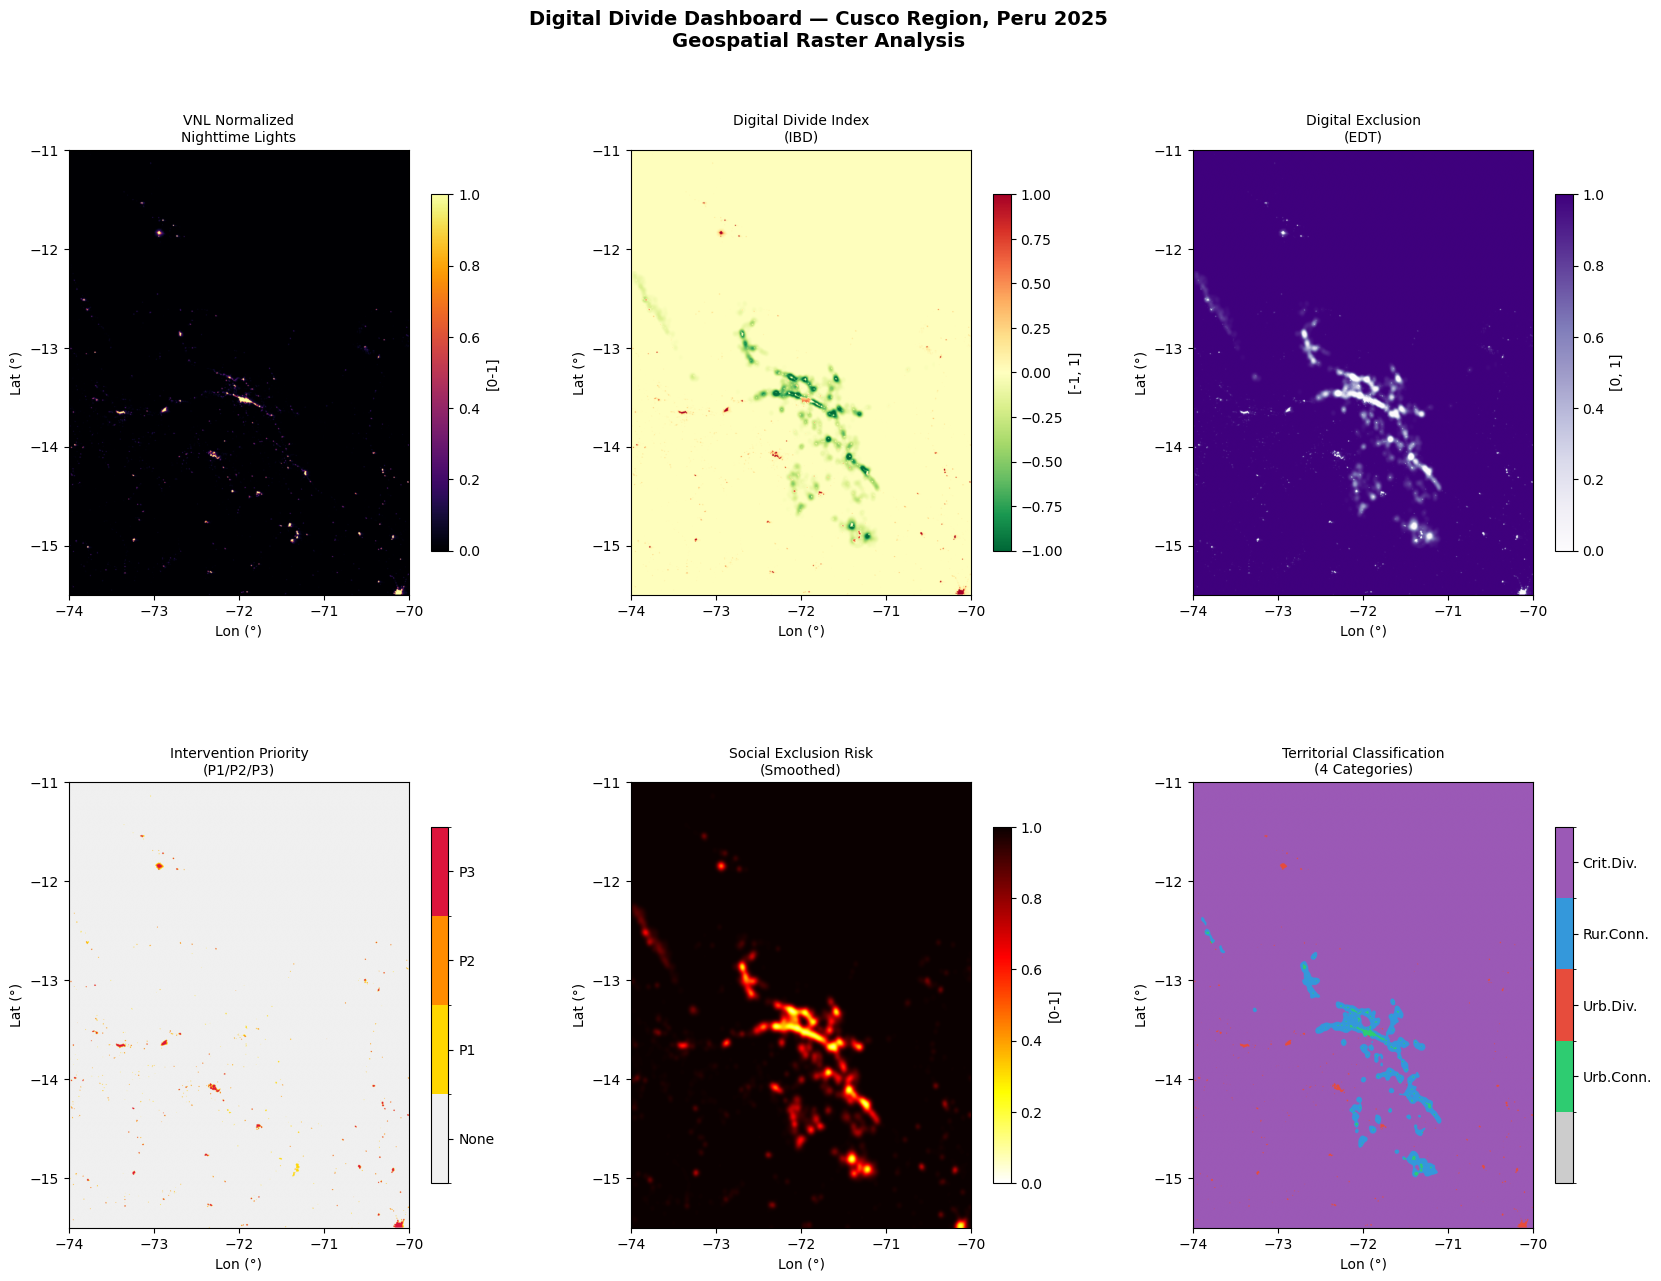

Saved: output/dashboard_brecha_digital.png

All deliverables exported successfully.


In [11]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import os

os.makedirs("../output", exist_ok=True)

def save_float_raster(arr, path, profile):
    prof = profile.copy()
    prof.update({"dtype": "float32", "count": 1, "nodata": -9999.0})
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(arr.astype(np.float32), 1)
    print(f"Saved: {path}")

save_float_raster(vnl_norm,  "../output/vnl_norm.tif",           vnl_profile)
save_float_raster(conn_norm, "../output/conn_norm.tif",          vnl_profile)
save_float_raster(IBD,       "../output/ibd_brecha_digital.tif", vnl_profile)
print("(clasificacion_brecha.tif already saved in Step 8)")

# Dashboard composite figure
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(vnl_norm, cmap="inferno", extent=extent, aspect="auto")
ax1.set_title("VNL Normalized\nNighttime Lights", fontsize=10)
ax1.set_xlabel("Lon (°)"); ax1.set_ylabel("Lat (°)")
plt.colorbar(im1, ax=ax1, shrink=0.8, label="[0-1]")

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(IBD, cmap="RdYlGn_r", extent=extent, aspect="auto", vmin=-1, vmax=1)
ax2.set_title("Digital Divide Index\n(IBD)", fontsize=10)
ax2.set_xlabel("Lon (°)"); ax2.set_ylabel("Lat (°)")
plt.colorbar(im2, ax=ax2, shrink=0.8, label="[-1, 1]")

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(EDT, cmap="Purples", extent=extent, aspect="auto", vmin=0, vmax=1)
ax3.set_title("Digital Exclusion\n(EDT)", fontsize=10)
ax3.set_xlabel("Lon (°)"); ax3.set_ylabel("Lat (°)")
plt.colorbar(im3, ax=ax3, shrink=0.8, label="[0, 1]")

cmap_p2 = mcolors.ListedColormap(["#f0f0f0", "#FFD700", "#FF8C00", "#DC143C"])
bnds_p2 = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_p2 = mcolors.BoundaryNorm(bnds_p2, cmap_p2.N)
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.imshow(priority, cmap=cmap_p2, norm=norm_p2, extent=extent, aspect="auto")
ax4.set_title("Intervention Priority\n(P1/P2/P3)", fontsize=10)
ax4.set_xlabel("Lon (°)"); ax4.set_ylabel("Lat (°)")
cb4 = plt.colorbar(im4, ax=ax4, shrink=0.8, ticks=[0,1,2,3])
cb4.ax.set_yticklabels(["None","P1","P2","P3"])

ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.imshow(risk_smooth, cmap="hot_r", extent=extent, aspect="auto", vmin=0, vmax=1)
ax5.set_title("Social Exclusion Risk\n(Smoothed)", fontsize=10)
ax5.set_xlabel("Lon (°)"); ax5.set_ylabel("Lat (°)")
plt.colorbar(im5, ax=ax5, shrink=0.8, label="[0-1]")

cmap_c2 = mcolors.ListedColormap(["#CCCCCC", "#2ECC71", "#E74C3C", "#3498DB", "#9B59B6"])
bnds_c2 = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm_c2 = mcolors.BoundaryNorm(bnds_c2, cmap_c2.N)
ax6 = fig.add_subplot(gs[1, 2])
im6 = ax6.imshow(classification, cmap=cmap_c2, norm=norm_c2, extent=extent, aspect="auto")
ax6.set_title("Territorial Classification\n(4 Categories)", fontsize=10)
ax6.set_xlabel("Lon (°)"); ax6.set_ylabel("Lat (°)")
cb6 = plt.colorbar(im6, ax=ax6, shrink=0.8, ticks=[1,2,3,4])
cb6.ax.set_yticklabels(["Urb.Conn.","Urb.Div.","Rur.Conn.","Crit.Div."])

fig.suptitle("Digital Divide Dashboard — Cusco Region, Peru 2025\nGeospatial Raster Analysis",
             fontsize=14, fontweight="bold")
plt.savefig("../output/dashboard_brecha_digital.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/dashboard_brecha_digital.png")
print("\nAll deliverables exported successfully.")